# Logistic Regression (Classification)

### Food Delivery Delay Prediction

### Step 1: Import Libraries

In [189]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

### Step 2: Load Dataset

In [190]:
df = pd.read_csv(r"D:\4th Semester\Machine Learning by Sir  Abdul Aziz\Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


### Step 3: Data Preprocessing

In [191]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [192]:
# Check Missing values by each column.
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [193]:
# Check Missing values of whole dataset
df.isnull().sum().sum()

np.int64(120)

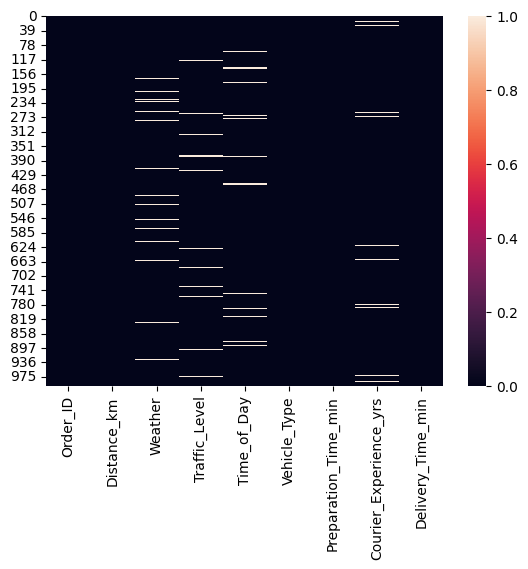

In [194]:
# Before Removing Missing values
sns.heatmap(df.isnull())
plt.show()

In [195]:
# Filling of missing entries in 'Weather','Traffic_Level','Time_of_Day' by mode due categorical data & 'Courier_Experience_yrs' by mean due numerical data.
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())

In [196]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

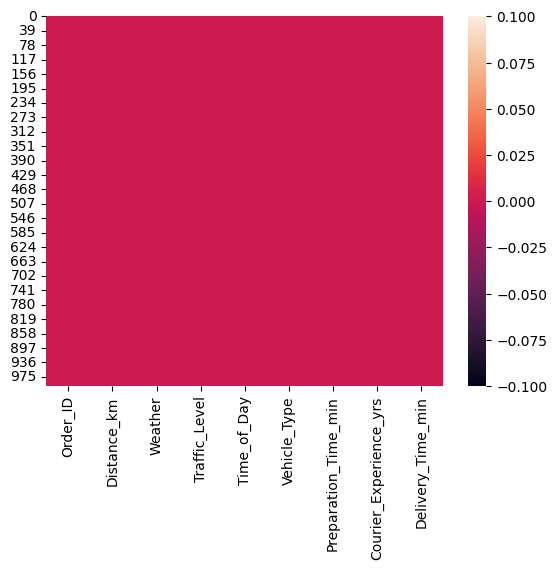

In [197]:
# After Removing Missing values
sns.heatmap(df.isnull())
plt.show()

### Step 4: Data Encoding

In [198]:
# Select string columns
df.select_dtypes(include='str').columns

Index(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], dtype='str')

In [199]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Weather'] = le.fit_transform(df['Weather'])

In [200]:
# Ordinal Encoding
df['Traffic_Level'].unique()

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

In [201]:
order = [['Low', 'Medium', 'High']]
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=order)
df['Traffic_Level'] = oe.fit_transform(df[['Traffic_Level']])

In [202]:
df['Time_of_Day'].unique()

<StringArray>
['Afternoon', 'Evening', 'Night', 'Morning']
Length: 4, dtype: str

In [203]:
order_t = [['Morning','Afternoon','Evening','Night']]
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=order_t)
df['Time_of_Day'] = oe.fit_transform(df[['Time_of_Day']])

In [204]:
le = LabelEncoder()
df['Vehicle_Type'] = le.fit_transform(df['Vehicle_Type'])

In [205]:
df.head(10)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,4,0.0,1.0,2,12,1.0,43
1,738,16.42,0,1.0,2.0,0,20,2.0,84
2,741,9.52,1,0.0,3.0,2,28,1.0,59
3,661,7.44,2,1.0,1.0,2,5,1.0,37
4,412,19.03,0,0.0,0.0,0,16,5.0,68
5,679,19.40,0,0.0,2.0,2,8,9.0,57
6,627,9.52,0,0.0,0.0,0,12,1.0,49
7,514,17.39,0,1.0,2.0,2,5,6.0,46
8,860,1.78,3,0.0,2.0,1,20,6.0,35
9,137,10.62,1,0.0,2.0,2,29,1.0,73


### Step 5: Standardization

In [206]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Order_ID'] = scaler.fit_transform(df[['Order_ID']])

In [207]:
df['Distance_km'] = scaler.fit_transform(df[['Distance_km']])

In [208]:
df['Delivery_Time_min'] = scaler.fit_transform(df[['Delivery_Time_min']])

In [209]:
df['Preparation_Time_min'] = scaler.fit_transform(df[['Preparation_Time_min']])

In [232]:
# Make late delivery column
df['Late_Delivery'] = df['Delivery_Time_min'].apply( lambda x: 1 if x > 0.5 else 0)

In [233]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Late_Delivery
0,0.074478,-0.374085,4,0.0,1.0,2,-0.691853,1.0,-0.622488,0
1,0.822725,1.117008,0,1.0,2.0,0,0.419111,2.0,1.236090,1
2,0.833117,-0.094835,1,0.0,3.0,2,1.530076,1.0,0.102811,0
3,0.555989,-0.460144,2,1.0,1.0,2,-1.663947,1.0,-0.894475,0
4,-0.306573,1.575401,0,0.0,0.0,0,-0.136371,5.0,0.510792,1


In [234]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   float64
 1   Distance_km             1000 non-null   float64
 2   Weather                 1000 non-null   int64  
 3   Traffic_Level           1000 non-null   float64
 4   Time_of_Day             1000 non-null   float64
 5   Vehicle_Type            1000 non-null   int64  
 6   Preparation_Time_min    1000 non-null   float64
 7   Courier_Experience_yrs  1000 non-null   float64
 8   Delivery_Time_min       1000 non-null   float64
 9   Late_Delivery           1000 non-null   int64  
dtypes: float64(7), int64(3)
memory usage: 78.3 KB


### Step 6: Split dataset into Train and Test

In [237]:
X = df[['Order_ID','Distance_km','Weather','Traffic_Level','Time_of_Day','Vehicle_Type','Preparation_Time_min','Courier_Experience_yrs','Delivery_Time_min']]
y = df['Late_Delivery']
X_train, X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 7: Apply Model

In [238]:
lo = LogisticRegression()
lo.fit(X_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Step 8: Prediction

In [240]:
y_predict = lo.predict(X_test)
print(y_predict)

[0 0 0 0 1 0 1 0 1 1 0 1 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0
 0 0 1 1 0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 1 0 1 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1
 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0
 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


### Step 9: Confusion Matrix

In [242]:
c = confusion_matrix(y_test, y_predict)
c

array([[140,   1],
       [  2,  57]])

### Step 10: Visualize confusion Matrix

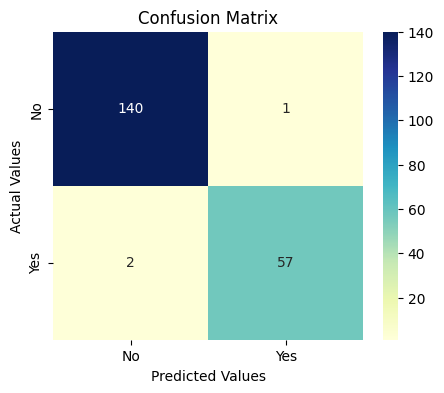

In [245]:
plt.figure(figsize=(5,4))
sns.heatmap(c,annot=True,fmt='d',cmap='YlGnBu',xticklabels=['No','Yes'],yticklabels=['No','Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')

plt.show()

In [248]:
# Report
from sklearn.metrics import classification_report
target = ['On Time','Late Delivery']
ce = classification_report(y_test, y_predict,target_names=target)
print(ce)

               precision    recall  f1-score   support

      On Time       0.99      0.99      0.99       141
Late Delivery       0.98      0.97      0.97        59

     accuracy                           0.98       200
    macro avg       0.98      0.98      0.98       200
 weighted avg       0.98      0.98      0.98       200



## At Last, I completed Logistic Regression !!!!!!!!!!!!